import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import dataset

In [5]:
train = pd.read_csv('/content/train.csv', on_bad_lines='skip')
test = pd.read_csv('/content/test.csv')

/tmp/ipykernel_906/55841261.py:2: DtypeWarning: Columns (463) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv('/content/test.csv')


Explore Dataset Information

In [6]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

print("\nTrain Missing Values:")
print(train.isnull().sum().sum())

print("\nTest Missing Values:")
print(test.isnull().sum().sum())

Train Shape: (1599, 563)
Test Shape: (2078, 563)

Train Missing Values:
546

Test Missing Values:
99


Handle Missing Values using mean imputation

In [9]:
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

X_train = train.drop("Activity", axis=1)
y_train = train["Activity"]

X_test = test.drop("Activity", axis=1)
y_test = test["Activity"]

# Convert all columns to numeric, coercing errors to NaN
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print("Train NaN:", np.isnan(X_train).sum())
print("Test NaN:", np.isnan(X_test).sum())

Train NaN: 0
Test NaN: 0


Label Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

encoder = LabelEncoder()

all_labels = np.concatenate([train["Activity"], test["Activity"]])

encoder.fit(all_labels)

y_train = encoder.transform(train["Activity"])
y_test = encoder.transform(test["Activity"])

y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

Reshape input data for cnn model

In [11]:
print(y_train.shape)
print(y_test.shape)

(1599, 7)
(2078, 7)


In [12]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)

(1599, 562, 1)
(2078, 562, 1)


Build the CNN

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv1D(64, 3, activation='relu', input_shape=(562, 1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(128, 3, activation='relu'))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 560, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 280, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 278, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 139, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 17792)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,277,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,303,367 (8.79 MB)

 Trainable params: 2,303,367 (8.79 MB)

 Non-trainable params: 0 (0.00 B)

Train the CNN Model

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.5647 - loss: 1.0733 - val_accuracy: 0.8210 - val_loss: 0.5484
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.8580 - loss: 0.3708 - val_accuracy: 0.8662 - val_loss: 0.3479
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.9162 - loss: 0.2257 - val_accuracy: 0.8503 - val_loss: 0.3770
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.9400 - loss: 0.1545 - val_accuracy: 0.8619 - val_loss: 0.3543
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.9562 - loss: 0.1298 - val_accuracy: 0.8845 - val_loss: 0.3400
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - accuracy: 0.9612 - loss: 0.1017 - val_accuracy: 0.8701 - val_loss: 0.3825
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.9769 - loss: 0.0723 - val_accuracy: 0.8884 - val_loss: 0.3233
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9744 - loss: 0.0736 - val_accuracy: 0

Evaluate Model Performance

In [15]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8840 - loss: 0.4885
Test Loss: 0.48852473497390747
Test Accuracy: 0.8840230703353882


Visualize Training and Validation performance

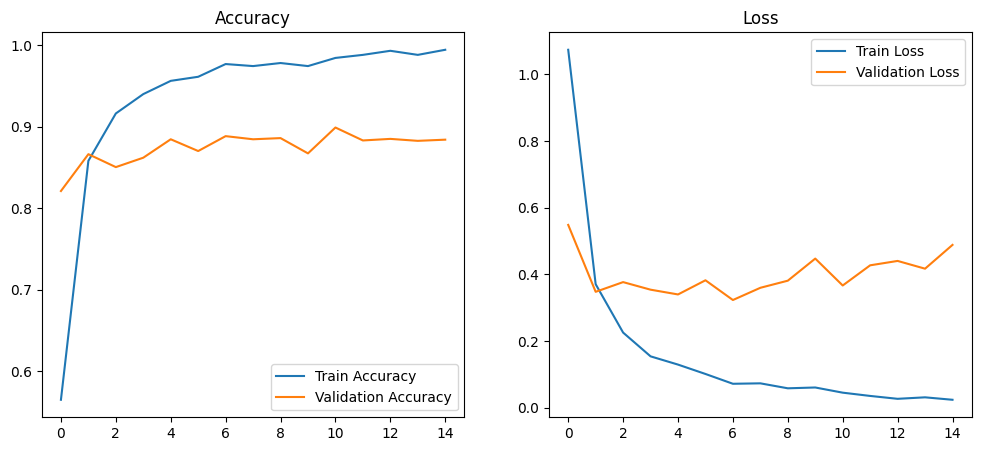

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

Save the trained CNN Model

In [17]:
model.save("human_activity_model.keras")

Download the Saved Model

In [20]:
from google.colab import files
files.download("human_activity_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
sample=test.drop("Activity",axis=1)
sample.head(1).to_csv("sample_input_csv",index=False)

In [21]:
from google.colab import files
files.download("sample_input_csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>